In [ ]:
#--------Batch Normalization--------批量归一化

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [6]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [7]:
# MLP revisited

n_embd = 10 # 字符嵌入向量的维度
n_hidden = 200 # 多层感知器（MLP）隐藏层中的神经元数量。

g = torch.Generator().manual_seed(2147483647) # 加入固定种子，为了可重复性
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

12097


In [8]:
# 沿用上一次的优化参数
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # 构建小批量数据 (minibatch)
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # 批次训练样本 X, 标签 Y
  
  # 前向传播 (forward pass)
  emb = C[Xb] # 将字符映射为特征向量 (embedding)
  embcat = emb.view(emb.shape[0], -1) # 将向量拼接起来 (保持 batch 维度)
  
  # 全连接层 (Linear layer)
  hpreact = embcat @ W1 # + b1 # 隐藏层的预激活值 (pre-activation)
  
  # 批归一化层 (BatchNorm layer)
  # -------------------------------------------------------------
  bnmeani = hpreact.mean(0, keepdim=True) # 计算当前批次的均值
  bnstdi = hpreact.std(0, keepdim=True)  # 计算当前批次的标准差
  
  # 对预激活值进行归一化，并使用可学习的增益(bngain)和偏置(bnbias)进行变换
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  
  with torch.no_grad():
    # 维护全局的均值和标准差的指数移动平均，用于推理阶段
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  
  # 非线性激活 (Non-linearity)
  h = torch.tanh(hpreact) # 隐藏层激活值
  logits = h @ W2 + b2 # 输出层
  loss = F.cross_entropy(logits, Yb) # 交叉熵损失函数
  
  # 反向传播 (backward pass)
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # 参数更新 (update)
  lr = 0.1 if i < 100000 else 0.01 # 学习率衰减逻辑
  for p in parameters:
    p.data += -lr * p.grad

  # 记录统计数据
  if i % 10000 == 0: # 定期打印训练进度
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0198
 190000/ 200000: 2.1707


In [9]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)
bnstd

tensor([[2.3180, 1.9779, 1.9661, 2.1366, 2.3308, 2.4496, 2.1545, 2.2389, 2.2520,
         2.0472, 2.4434, 2.2636, 2.0590, 2.1966, 1.9379, 2.7376, 2.4003, 1.8734,
         2.1654, 2.2979, 2.1763, 2.4675, 2.0542, 2.1448, 2.0734, 1.9834, 2.1899,
         2.6569, 2.4516, 2.3357, 1.6746, 1.8719, 2.0306, 1.9018, 2.1751, 2.0201,
         2.6048, 2.0686, 1.7246, 1.8847, 2.1271, 2.0575, 2.4424, 1.9899, 2.1021,
         2.4055, 2.1443, 2.6659, 2.2895, 2.5410, 2.1197, 1.8970, 1.7952, 1.7494,
         2.4012, 2.2687, 1.8617, 2.2695, 2.4958, 1.7832, 2.2730, 2.1360, 2.0930,
         2.3763, 2.1851, 2.1275, 2.1396, 2.4145, 1.9595, 2.2082, 2.2145, 1.9846,
         1.9964, 2.3310, 1.9104, 1.7241, 2.6101, 2.1843, 1.7922, 2.4059, 2.2133,
         1.7586, 2.0061, 2.2215, 2.4505, 2.2982, 2.1866, 2.3506, 2.2673, 2.4957,
         2.0521, 2.0157, 2.1269, 1.9221, 1.9355, 2.4288, 2.1265, 1.9726, 1.9275,
         2.2309, 2.1202, 1.9348, 2.3101, 2.1514, 1.9881, 2.2147, 2.0686, 2.1845,
         1.8946, 2.1217, 2.5

In [10]:
@torch.no_grad() # 这个装饰器会禁用梯度追踪
def split_loss(split):
#利用字典实现选择功能，根据split的值选择哪一组数据赋值给x，y
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd) # C(27,10) x(32,3) emb(32,3,10)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)隐藏层激活
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

# 评估各数据集上的损失
split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056838035583496


#---loss log---
#original:
train 2.1245384216308594 val 2.168196439743042

#fix softmax confidently wrong:
train 2.07 val 2.13

#fix tanh layer too saturated at init:
train 2.0355966091156006 val 2.1026785373687744

#use semi-principled "kaiming init" instead of hacky init:
train 2.0376641750335693 val 2.106989622116089

#add batch norm layer
train 2.0668270587921143 val 2.104844808578491

In [ ]:
# SUMMARY + PYTORCHIFYING -----------

In [11]:
# 我们来训练一个更深的网络
# 这里创建的类具有和 PyTorch 中 nn.Module 相同的 API 结构

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    # Kaiming 初始化：除以 fan_in 的平方根是为了防止在前向传播时数值爆炸
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True # 只有训练时才计算批次的均值方差
    # 参数 (通过反向传播训练)
    self.gamma = torch.ones(dim)  # 缩放因子
    self.beta = torch.zeros(dim)  # 偏移因子
    # 缓冲区 (通过运行时的“动量更新”来维护，不参与梯度下降)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # 计算前向传播
    if self.training:
      xmean = x.mean(0, keepdim=True) # 批次均值
      xvar = x.var(0, keepdim=True)   # 批次方差
    else:
      xmean = self.running_mean
      xvar = self.running_var
    
    # 归一化到单位方差
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) 
    self.out = self.gamma * xhat + self.beta
    
    # 在训练时更新全局统计量 (running stats)
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# --- 超参数与初始化 ---

n_embd = 10      # 字符向量的维度
n_hidden = 100   # MLP 隐藏层中神经元的数量
g = torch.Generator().manual_seed(2147483647) 

C = torch.randn((vocab_size, n_embd), generator=g)

# 构建多层网络
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

# 权重初始化调整
with torch.no_grad():
  # 最后一层：让模型在初始化时“没那么自信”，防止初始 Loss 爆炸
  layers[-1].gamma *= 0.1
  # 对其他所有层应用增益 (Gain)
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 # 如果使用 Tanh，理想的增益通常是 5/3，这里设为 1 是配合 BN 使用

# 收集所有参数
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(f"总参数量: {sum(p.nelement() for p in parameters)}")

# 激活所有参数的梯度记录
for p in parameters:
  p.requires_grad = True

总参数量: 47024


In [12]:
# 沿用上一次的优化参数
max_steps = 200000
batch_size = 32
lossi = []
ud = [] # 用于记录更新量与参数比例 (update-to-data ratio)

for i in range(max_steps):
  
  # 构建小批量数据 (minibatch)
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # 批次训练样本 X, 标签 Y
  
  # 前向传播 (forward pass)
  emb = C[Xb] # 将字符映射为特征向量
  x = emb.view(emb.shape[0], -1) # 拼接向量
  for layer in layers:
    x = layer(x) # 自动流经所有层：Linear -> BN -> Tanh ...
  loss = F.cross_entropy(x, Yb) # 计算损失
  
  # 反向传播 (backward pass)
  for layer in layers:
    # 调试用：保留中间层的梯度以便后续分析。正式训练时可删除此行
    layer.out.retain_grad() 
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # 参数更新 (update)
  lr = 0.1 if i < 150000 else 0.01 # 步进式学习率衰减
  for p in parameters:
    p.data += -lr * p.grad

  # 记录统计数据
  if i % 10000 == 0: # 定期打印进度
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  
  # 记录更新比例：反映学习率是否合适
  with torch.no_grad():
    # 计算 (步长 * 梯度) 的标准差与 (参数本身) 的标准差之比
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # 调试用：运行1000次后自动停止
  if i >= 1000:
    break # 调试结束后请删除此行以进行完整训练

      0/ 200000: 3.2870


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.78%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.56%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.25%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.69%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.88%


Text(0.5, 1.0, 'activation distribution')

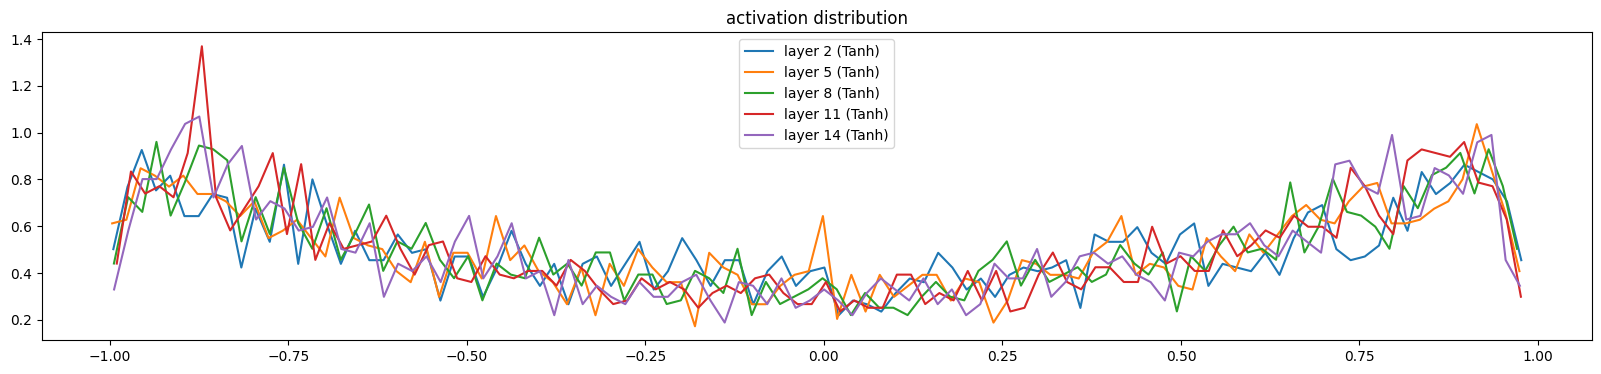

In [13]:
# visualize histograms (可视化直方图)
plt.figure(figsize=(20, 4)) # 设置图表宽度和高度
legends = []

for i, layer in enumerate(layers[:-1]): # 注意：排除输出层
  if isinstance(layer, Tanh):
    t = layer.out
    # 打印该层的统计信息：均值、标准差、饱和度
    # 使用 .item() 转换标量以消除警告
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (
        i, 
        layer.__class__.__name__, 
        t.mean().item(), 
        t.std().item(), 
        (t.abs() > 0.97).float().mean().item() * 100
    ))
    
    # 计算直方图数据
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('activation distribution') #激活层分布

layer 2 (      Tanh): mean +0.000000, std 2.640702e-03
layer 5 (      Tanh): mean -0.000000, std 2.245584e-03
layer 8 (      Tanh): mean +0.000000, std 2.045742e-03
layer 11 (      Tanh): mean -0.000000, std 1.983134e-03
layer 14 (      Tanh): mean +0.000000, std 1.952382e-03


Text(0.5, 1.0, 'gradient distribution')

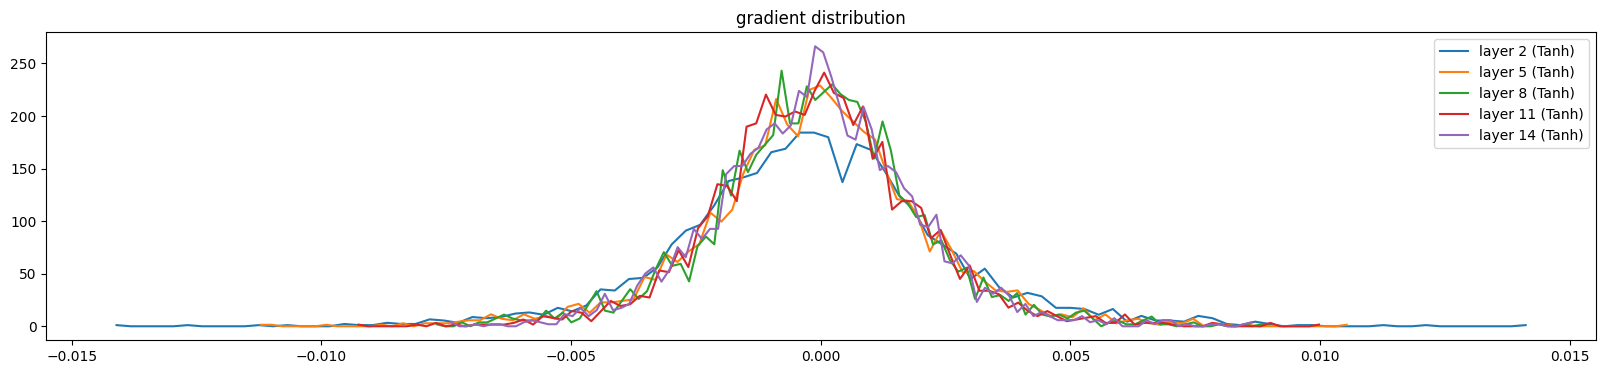

In [14]:
# 可视化直方图
plt.figure(figsize=(20, 4)) # 设置图表的宽度和高度
legends = []

for i, layer in enumerate(layers[:-1]): # 注意：排除输出层
  if isinstance(layer, Tanh):
    t = layer.out.grad # 注意：这里获取的是梯度的分布情况
    # 打印该层的梯度统计信息：均值、标准差
    # 使用 %e 是因为梯度通常非常小（例如 1e-4），科学计数法更易观察
    print('layer %d (%10s): mean %+f, std %e' % (
        i, 
        layer.__class__.__name__, 
        t.mean().item(), 
        t.std().item()
    ))
    
    # 计算直方图
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title('gradient distribution') # 标题：梯度分布

weight   (27, 10) | mean +0.000000 | std 8.020533e-03 | grad:data ratio 8.012629e-03
weight  (30, 100) | mean +0.000246 | std 9.241073e-03 | grad:data ratio 4.881089e-02
weight (100, 100) | mean +0.000113 | std 7.132879e-03 | grad:data ratio 6.964619e-02
weight (100, 100) | mean -0.000086 | std 6.234303e-03 | grad:data ratio 6.073739e-02
weight (100, 100) | mean +0.000052 | std 5.742187e-03 | grad:data ratio 5.631482e-02
weight (100, 100) | mean +0.000032 | std 5.672205e-03 | grad:data ratio 5.570126e-02
weight  (100, 27) | mean -0.000082 | std 1.209416e-02 | grad:data ratio 1.160106e-01


Text(0.5, 1.0, 'weights gradient distribution')

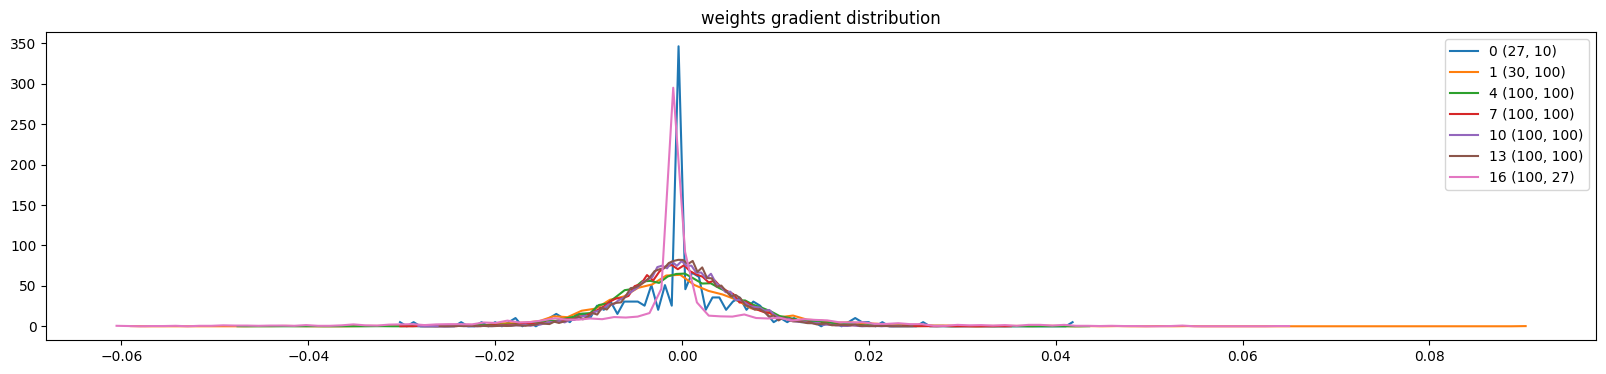

In [15]:
# 可视化直方图
plt.figure(figsize=(20, 4)) # 设置图表的宽度和高度
legends = []

for i, p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # 只观察二维张量，通常是权重矩阵（Weights），排除偏置（Bias）和缩放因子
    # 打印权重的统计信息：形状 | 均值 | 标准差 | 梯度与数据的比例
    # grad:data ratio 反映了梯度更新相对于参数量级的大小
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (
        tuple(p.shape), 
        t.mean().item(), 
        t.std().item(), 
        (t.std() / p.std()).item()
    ))
    
    # 计算直方图
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    # 记录图例：索引 + 参数形状
    legends.append(f'{i} {tuple(p.shape)}')

plt.legend(legends)
plt.title('weights gradient distribution') # 标题：权重梯度分布

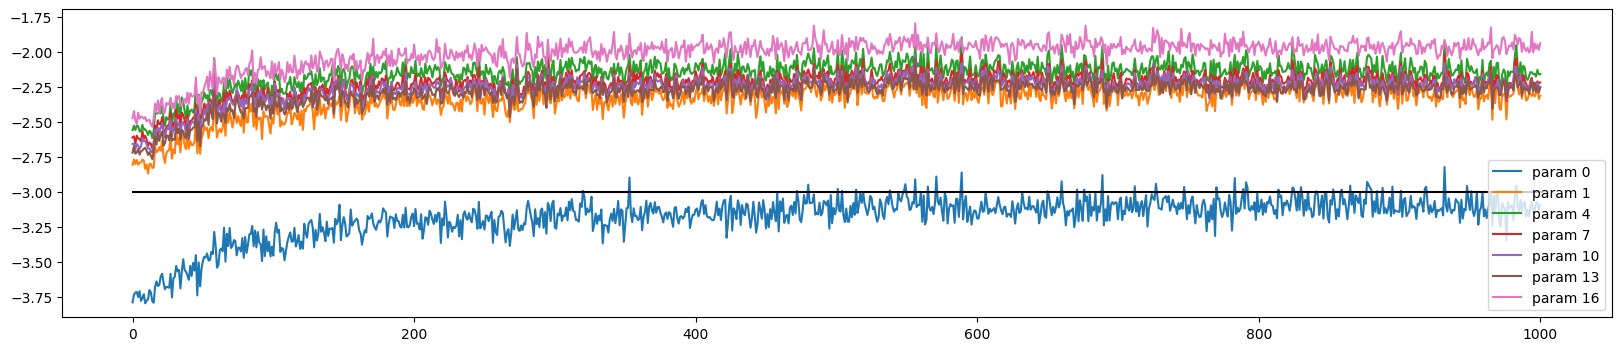

In [16]:
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
  if p.ndim == 2: # 只观察二维权重的更新情况
    # 提取第 i 个参数在所有迭代步中的记录值，并画图
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)

# 在图中画一条黑色参考线（y = -3），代表比例应该在 1e-3 左右
plt.plot([0, len(ud)], [-3, -3], 'k') 
plt.legend(legends)

In [25]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.4002976417541504
val 2.398247003555298


In [26]:
# 从模型中采样（生成名字）
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20): # 生成 20 个名字
    
    out = []
    context = [0] * block_size # 初始化上下文，用 '.' 对应的索引 0 填充
    while True:
      # 前向传播神经网络
      emb = C[torch.tensor([context])] # 嵌入层：将字符索引转换为向量 (1, block_size, n_embd)
      x = emb.view(emb.shape[0], -1)   # 拉平向量：准备输入全连接层
      for layer in layers:
        x = layer(x)                   # 自动流经所有训练好的层
      
      logits = x
      probs = F.softmax(logits, dim=1) # 将输出转换为概率分布
      
      # 根据概率分布进行多项式采样
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      
      # 移动上下文窗口：去掉第一个字符，在末尾加上新采样的字符
      context = context[1:] + [ix]
      out.append(ix)
      
      # 如果采样到了特殊的结束符 '.' (索引为 0)，则停止生成
      if ix == 0:
        break
    
    # 将索引转换回字符并打印生成的单词
    print(''.join(itos[i] for i in out))

carpah.
qarlileif.
jmrix.
thty.
sacansa.
jazhnte.
dpn.
arciigqeiunellaia.
chriiv.
kalein.
dhlm.
join.
qhinn.
sroin.
arian.
quiqaelogiearyxix.
kaeklinsan.
ed.
ecoia.
gtleley.


In [ ]:
#-------后续------

interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

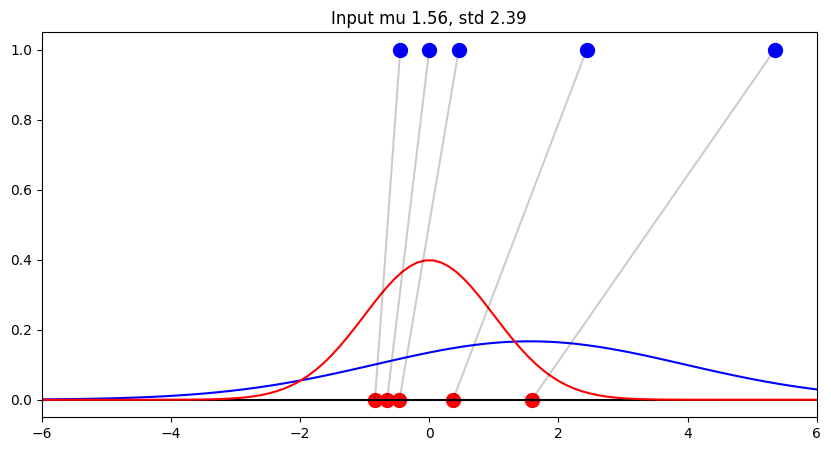

In [32]:
# 将 BatchNorm 的前向传播作为一个交互式组件 (widget)
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5 # 随机生成 5 个原始数据点，并放大 5 倍
  x[0] = x0 # 用滑块控制的值覆盖掉第 0 个样本点
  mu = x.mean() # 计算当前这组数据的均值
  sig = x.std() # 计算当前这组数据的标准差
  y = (x - mu)/sig # 执行归一化：减去均值并除以标准差

  plt.figure(figsize=(10, 5))
  # 绘制底部的基准线 (y=0)
  plt.plot([-6,6], [0,0], 'k')
  
  # 绘制均值和标准差的分布曲线
  xx = np.linspace(-6, 6, 100)
  # 蓝色线：归一化前的输入数据分布
  plt.plot(xx, stats.norm.pdf(xx, mu.item(), sig.item()), 'b') 
  xx = np.linspace(-6, 6, 100)
  # 红色线：归一化后的标准正态分布 (0, 1)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')    
  
  # 绘制连接输入点和输出点的细线，观察它们是如何移动的
  for i in range(len(x)):
    plt.plot([x[i].item(), y[i].item()], [1, 0], 'k', alpha=0.2)
  
  # 绘制输入值和输出值的数据点
  plt.scatter(x.data.cpu(), torch.ones_like(x).data.cpu(), c='b', s=100)  # 蓝色点：输入值 (位于 y=1 高度)
  plt.scatter(y.data.cpu(), torch.zeros_like(y).data.cpu(), c='r', s=100) # 红色点：输出值 (位于 y=0 高度)
  
  plt.xlim(-6, 6)
  # 设置标题，实时显示当前的均值和标准差
  # 使用英文标题避免字体缺失导致的方框问题
  plt.title('Input mu %.2f, std %.2f' % (mu.item(), sig.item()))

# 启动交互，x0 的调节范围是 -30 到 30，步长为 0.5
interact(normshow, x0=(-30,30,0.5));

In [30]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [33]:
# Linear + BatchNorm: 前向传播与反向传播的激活值统计
g = torch.Generator().manual_seed(2147483647)
n = 1000

# 线性层 (Linear layer) ---
inp = torch.randn(n, requires_grad=True, generator=g)
# 注意：这里注释掉了 / n**0.5，这意味着我们使用的是标准正态初始化（未经过缩放）
w = torch.randn((n, n), requires_grad=True, generator=g) 
x = w @ inp

# 批归一化层 (BN layer) ---
xmean = x.mean()
xvar = x.var()
out = (x - xmean) / torch.sqrt(xvar + 1e-5) # 将 x 强制转变为 均值0, 方差1 的分布

# ---- 计算损失并反向传播 ----
loss = out @ torch.randn(n, generator=g)

# 保留中间变量的梯度以便观察
inp.retain_grad()
x.retain_grad()
w.retain_grad()
out.retain_grad()

loss.backward()

# 打印前向传播的统计数据
print('输入标准差 (inp std): ', inp.std().item())
print('权重标准差 (w std):   ', w.std().item())
print('线性输出标准差 (x std): ', x.std().item()) # 这里你会看到数值爆炸
print('BN输出标准差 (out std):', out.std().item()) # 这里数值被拉回到 1
print('------')
# 打印反向传播（梯度）的统计数据
print('out 梯度标准差: ', out.grad.std().item())
print('x 梯度标准差:   ', x.grad.std().item())
print('w 梯度标准差:   ', w.grad.std().item())
print('inp 梯度标准差: ', inp.grad.std().item())

输入标准差 (inp std):  0.9875972270965576
权重标准差 (w std):    1.0006722211837769
线性输出标准差 (x std):  31.01241683959961
BN输出标准差 (out std): 1.0
------
out 梯度标准差:  0.9782556295394897
x 梯度标准差:    0.031543977558612823
w 梯度标准差:    0.031169468536973
inp 梯度标准差:  0.9953054189682007
